In [1]:
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Polygon
import numpy as np
from pathlib import Path
#imports
import geopandas as gpd
import rasterstats
import rasterio
import pandas as pd
import numpy as np
from pathlib import Path
import geopandas as gpd
import esda
import libpysal as lps
import matplotlib.pyplot as plt


In [2]:
points = gpd.read_file('Dhaka_Boundary/Dhaka_District_Boundary.shp')
print(points.crs) #4326: coords are stored as lat/lon in degrees

#this is bad for distance/area calc, if i want to make 1km grid, then 1km here means 1000 degrees, which is meaningless
#converting to 32645 where units are metres, now 1000 means 1000 metres exactly
points = points.to_crs(epsg=32645)
# get the bounding box of the boudnary
# total_bounds returns:
#   xmin = left edge
#   ymin = bottom edge
#   xmax = right edge
#   ymax = top edge
#
# Think of it as the smallest rectangle that completely contains Dhaka.

xmin, ymin, xmax, ymax = points.total_bounds

#define grid cell size
length = 1000
wide = 1000

# Create x coordinates for vertical grid lines.
cols = list(np.arange(xmin, xmax + wide, wide))
# Create y coordinates for horizontal grid lines.
rows = list(np.arange(ymin, ymax + length, length))

polygons = []
for x in cols[:-1]:
    for y in rows[:-1]:
         # Create one square polygon.
        #
        # Corner order:
        #   bottom-left
        #   bottom-right
        #   top-right
        #   top-left
        #
        # Example square:
        #
        # (x,y+1000) -------- (x+1000,y+1000)
        #      |                     |
        #      |                     |
        #      |                     |
        #    (x,y) ----------- (x+1000,y)
        #
        # Each polygon represents one 1km x 1km grid cell.
        polygons.append(Polygon([(x,y), (x+wide, y), (x+wide, y+length), (x, y+length)]))

# Convert the list of polygons into a GeoDataFrame.
#
# Now every row represents one grid cell geometry.
#
# CRS is set to EPSG:32645 because grid coordinates are in meters.
grid = gpd.GeoDataFrame({'geometry':polygons}, crs=32645)
# clip to Dhaka as the bounding box covers areas outside Dhaka too
grid_clipped = gpd.overlay(grid, points, how='intersection')

# save clipped grid

Path("outputs/grid").mkdir(parents=True, exist_ok=True)

grid_clipped.to_file("outputs/grid/grid.shp")
grid=grid_clipped

EPSG:4326


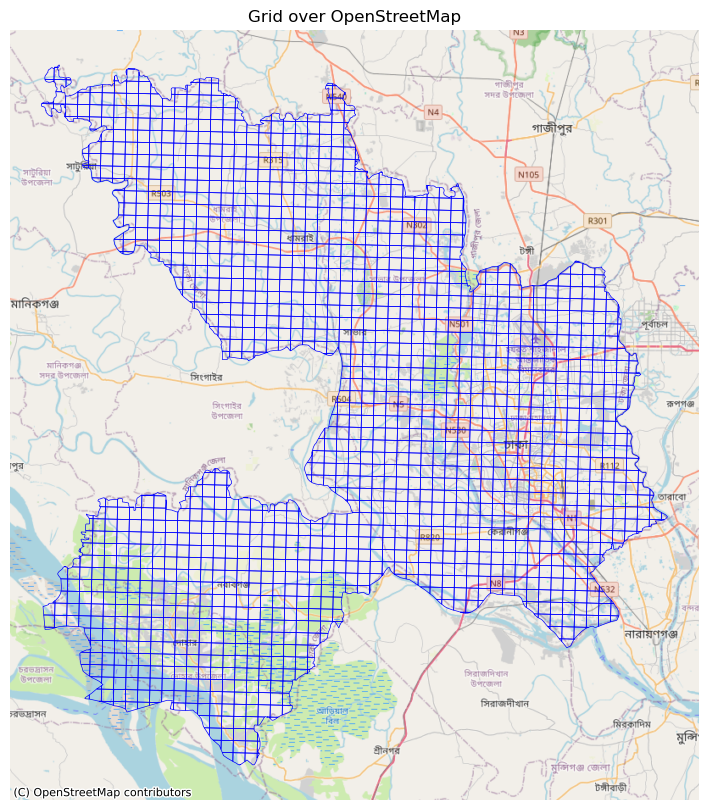

In [27]:
import matplotlib.pyplot as plt
import contextily as ctx

# Convert to Web Mercator (required for OSM tiles)
grid_3857 = grid_clipped.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot grid boundaries
grid_3857.boundary.plot(
    ax=ax,
    linewidth=0.5,
    color="blue"
)

# Add OpenStreetMap basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

ax.set_axis_off()
ax.set_title("Grid over OpenStreetMap")

plt.show()

# Zonal Statictics
Summarizing raster values inside geographic regions (zones).
* zone is usually a polygon
* raster is pixel-based data

* our workflow:
Dhaka boundary
      ↓
Create 1km grid cells
      ↓
For each grid cell:
    summarize raster values
      ↓
Output:
each cell gets statistics

In [4]:
#Path to exported Rasters
data_dir = Path("rasters")          
#Path to 1km x 1km grid
#each grid cell will become one "zone"
grid_path = "outputs/grid/grid.shp"              

# Raster paths 
rasters = {
    'NDVI_p50':  data_dir / 'Dhaka_NDVI_p50.tif',
    'NDBI_p50':  data_dir / 'Dhaka_NDBI_p50.tif',
    'LST_p50':   data_dir / 'Dhaka_LST_p50.tif',
    'Population': data_dir / 'Dhaka_WorldPop2024.tif',
    'LST_p90':   data_dir / 'Dhaka_LST_p90.tif',
}

In [5]:
# Load grid
print("Loading grid...")
grid = gpd.read_file(grid_path).to_crs(epsg=32645)  # Make sure it's in same CRS as rasters
print(f"Grid has {len(grid)} cells")

# Otherwise polygons may appear in the wrong location
# relative to raster pixels.
#polygons and pixels won't overlap correctly

#this grid has 1659 cells that means zonal stats will run 1650 times (once per polygon)

Loading grid...
Grid has 1659 cells


In [6]:
#computes raster summaries within each 
for var_name, raster_path in rasters.items():
    print(f"Processing {var_name}...")
    
    if "Population" in var_name:
        # total population inside a cell matters.
        stats = rasterstats.zonal_stats(
            grid, str(raster_path),
            stats=['sum', 'mean'],
             #ignore invalid raster pixels
            nodata=-9999,
            #return plain dictionaries instead of GeoJSON features
            geojson_out=False
        )
        grid['pop_sum'] = [x['sum'] for x in stats]
        grid['pop_mean'] = [x['mean'] for x in stats]
        
    else:
        # For NDVI, NDBI, LST
        stats = rasterstats.zonal_stats(
            grid, str(raster_path),
            stats=['mean', 'std', 'min', 'max'],
            nodata=-9999,
            geojson_out=False
        )
        grid[f'{var_name}_mean'] = [x['mean'] for x in stats]
        grid[f'{var_name}_std']  = [x['std'] for x in stats]
        grid[f'{var_name}_min'] = [x['min'] for x in stats]
        grid[f'{var_name}_max'] = [x['max'] for x in stats]



Processing NDVI_p50...
Processing NDBI_p50...
Processing LST_p50...
Processing Population...
Processing LST_p90...


# Population Weighted Measures

* value * population/pop 

grid cell = analysis unit

- STEP 1: compute mean NDVI/LST per cell
- STEP 2: attach population per cell
- STEP 3:
    - simple mean → treat all cells equal
    - weighted mean → weight by population

In [7]:
print("Calculating population-weighted values...")

# Create mask for cells with population
pop_mask = grid['pop_sum'] > 10

# Apply mask once (important for consistency)
grid = grid[pop_mask].copy()

for var in ['NDVI_p50', 'NDBI_p50', 'LST_p50', 'LST_p90']:
    mean_col = f'{var}_mean'
    weighted_col = f'{var}_pop_weighted'
    
    if mean_col in grid.columns:
        # Simple way: (mean * population) / total pop per cell
        grid[weighted_col] = grid[mean_col] * grid['pop_sum']
        # Note: We will normalize later when doing city-wide or per-cell analysis
        
# Final weighted calculation (per grid cell)
total_pop = grid['pop_sum'].sum()

# CITY-WIDE SIMPLE MEAN
# This gives the "average condition of space"
# Each 1km grid cell is treated equally, regardless of how many people live there.
#
# Interpretation:
# → "What is the typical NDVI/LST/NDBI across the city landscape?"
# → spatial average, NOT human-exposure weighted
city_simple = {
    'NDVI_simple_mean': grid['NDVI_p50_mean'].mean(),
    'NDBI_simple_mean': grid['NDBI_p50_mean'].mean(),
    'LST_simple_mean':  grid['LST_p50_mean'].mean(),
    'LST90_simple_mean': grid['LST_p90_mean'].mean(),
}

# CITY-WIDE POPULATION WEIGHTED MEAN
# This gives the "average condition experienced by people"
# Heavily populated areas contribute more to the final value.
#
# Interpretation:
# → "What is the environmental exposure experienced by an average person in the city?"
# → exposure-weighted spatial average
city_weighted = {
    'NDVI_pop_weighted': (grid['NDVI_p50_mean'] * grid['pop_sum']).sum() / total_pop,
    'NDBI_pop_weighted': (grid['NDBI_p50_mean'] * grid['pop_sum']).sum() / total_pop,
    'LST_pop_weighted':  (grid['LST_p50_mean'] * grid['pop_sum']).sum() / total_pop,
    'LST90_pop_weighted':(grid['LST_p90_mean'] * grid['pop_sum']).sum() / total_pop,
}

Calculating population-weighted values...


In [8]:
print("\n" + "="*60)
print("CITY-WIDE RESULTS")
print("="*60)
for k, v in city_simple.items():
    print(f"{k:25}: {v:.4f}")
for k, v in city_weighted.items():
    print(f"{k:25}: {v:.4f}")

# Save cleaned version
output_path = "outputs/grid/dhaka_grid_stats_clean.gpkg"

grid.to_file(output_path, driver="GPKG")

print(f"\n✅ Cleaned grid saved as: {output_path}")


CITY-WIDE RESULTS
NDVI_simple_mean         : 0.4632
NDBI_simple_mean         : -0.1791
LST_simple_mean          : 29.3174
LST90_simple_mean        : 36.4355
NDVI_pop_weighted        : 0.3952
NDBI_pop_weighted        : -0.1181
LST_pop_weighted         : 30.1734
LST90_pop_weighted       : 37.7543

✅ Cleaned grid saved as: outputs/grid/dhaka_grid_stats_clean.gpkg


In [9]:
grid.columns

Index(['adm0_name', 'center_lon', 'adm1_name3', 'adm2_name', 'adm0_pcode',
       'valid_on', 'version', 'adm2_name3', 'adm2_name2', 'adm2_name1',
       'center_lat', 'adm2_ref_n', 'area_sqkm', 'adm1_pcode', 'adm1_name',
       'adm1_name1', 'adm1_name2', 'adm2_pcode', 'lang3', 'lang2',
       'adm0_name2', 'lang1', 'lang', 'adm0_name3', 'adm0_name1', 'geometry',
       'NDVI_p50_mean', 'NDVI_p50_std', 'NDVI_p50_min', 'NDVI_p50_max',
       'NDBI_p50_mean', 'NDBI_p50_std', 'NDBI_p50_min', 'NDBI_p50_max',
       'LST_p50_mean', 'LST_p50_std', 'LST_p50_min', 'LST_p50_max', 'pop_sum',
       'pop_mean', 'LST_p90_mean', 'LST_p90_std', 'LST_p90_min', 'LST_p90_max',
       'NDVI_p50_pop_weighted', 'NDBI_p50_pop_weighted',
       'LST_p50_pop_weighted', 'LST_p90_pop_weighted'],
      dtype='object')

In [10]:
grid = gpd.read_file("outputs/grid/dhaka_grid_stats_clean.gpkg")
print("\nSummary Statistics:")
print(grid[['NDVI_p50_mean', 'NDBI_p50_mean', 'LST_p50_mean', 'LST_p90_mean', 
            'NDVI_p50_pop_weighted', 'LST_p50_pop_weighted', 'pop_sum']].describe().round(3))



Summary Statistics:
       NDVI_p50_mean  NDBI_p50_mean  LST_p50_mean  LST_p90_mean  \
count       1551.000       1551.000      1551.000      1551.000   
mean           0.463         -0.179        29.317        36.436   
std            0.129          0.083         1.480         2.027   
min           -0.114         -0.338        23.832        29.347   
25%            0.383         -0.243        28.191        34.853   
50%            0.512         -0.207        29.261        35.940   
75%            0.566         -0.116        30.285        37.870   
max            0.648          0.043        36.052        44.035   

       NDVI_p50_pop_weighted  LST_p50_pop_weighted    pop_sum  
count               1551.000              1551.000   1551.000  
mean                3114.305            237797.795   7881.030  
std                 2493.270            238588.051   7631.377  
min                  -41.571               295.950     10.217  
25%                  986.957             59628.962   20

# Spatial Autocorrelation (Moran’s I + LISA)

# Choosing Weighting Strategy

In [11]:
# Load cleaned data
gdf = gpd.read_file("outputs/grid/dhaka_grid_stats_clean.gpkg")

"""
We used Queen contiguity weights because the data consist of a regular grid of urban environmental variables (LST, NDVI, etc.), where spatial processes are expected to operate across both edges and corners.
"""
# Create spatial weights (Queen contiguity)
w = lps.weights.Queen.from_dataframe(gdf)
w.transform = 'r'   # row-standardized
print(f"Observations: {w.n}")
print(f"Average neighbors per cell: {w.mean_neighbors:.2f}")

w_rook = lps.weights.Rook.from_dataframe(gdf)
w_rook.transform = 'R'
print(f"Observations: {w_rook.n}")
print(f"Average neighbors per cell: {w_rook.mean_neighbors:.2f}")
# Compare Moran's I
moran_queen = esda.Moran(gdf['LST_p50_mean'], w)
moran_rook = esda.Moran(gdf['LST_p50_mean'], w_rook)
print("queen",moran_queen.I,"rook", moran_rook.I)

print("Islands (Queen):", len(w.islands))
print("Rook islands: ", len(w_rook.islands))

Observations: 1551
Average neighbors per cell: 7.32
Observations: 1551
Average neighbors per cell: 3.75
queen 0.7734126056174677 rook 0.7926242017524063
Islands (Queen): 0
Rook islands:  0


C:\Users\Cybertronia\AppData\Local\Temp\ipykernel_5112\1209553029.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = lps.weights.Queen.from_dataframe(gdf)
C:\Users\Cybertronia\AppData\Local\Temp\ipykernel_5112\1209553029.py:13: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_rook = lps.weights.Rook.from_dataframe(gdf)


C:\Users\Cybertronia\AppData\Local\Temp\ipykernel_5112\4272011955.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen_sample = lps.weights.Queen.from_dataframe(sample)
C:\Users\Cybertronia\AppData\Local\Temp\ipykernel_5112\4272011955.py:9: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_rook_sample  = lps.weights.Rook.from_dataframe(sample)


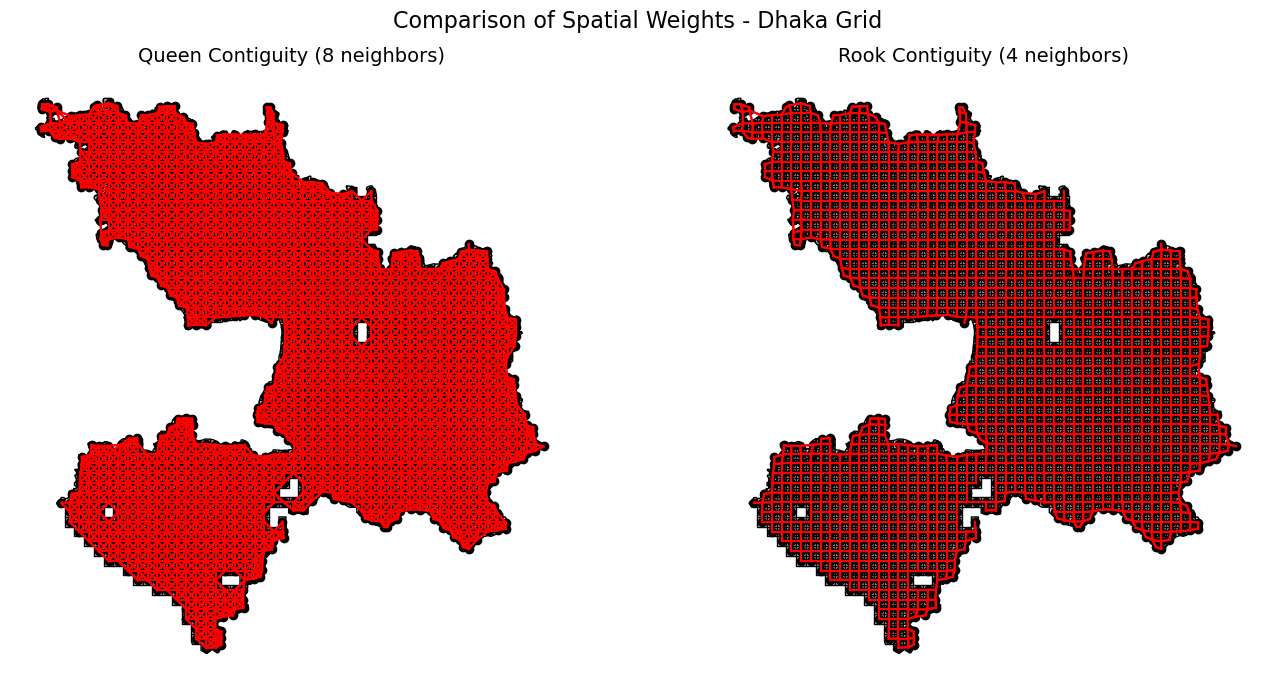

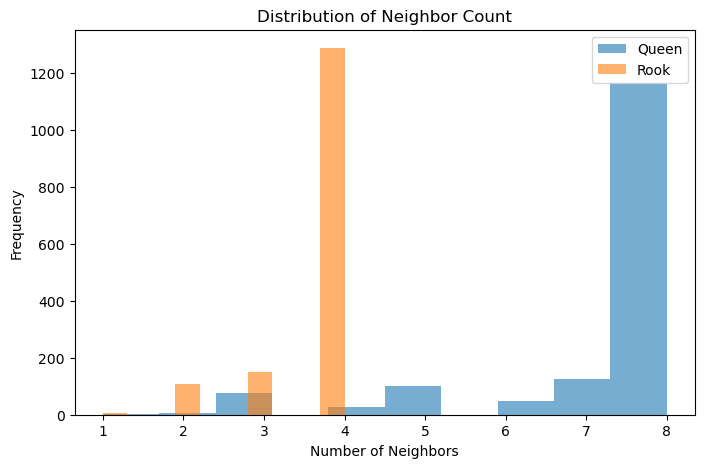

In [12]:
# Reset index to ensure clean, sequential indexing for spatial weights construction
# (important because PySAL expects consistent row alignment)
sample = gdf.reset_index(drop=True)  

# Construct spatial weight matrices using two different adjacency rules:
# 1. Queen contiguity → shares either edges OR corners (8-direction connectivity)
# 2. Rook contiguity  → shares only edges (4-direction connectivity)
w_queen_sample = lps.weights.Queen.from_dataframe(sample)
w_rook_sample  = lps.weights.Rook.from_dataframe(sample)

# VISUAL COMPARISON

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Queen contiguity visualization
# Each polygon is connected to all touching neighbors (including diagonals)
sample.plot(ax=axes[0], facecolor='lightgray', edgecolor='black')
w_queen_sample.plot(sample, ax=axes[0], edge_kws=dict(color='red', linewidth=1.5))
axes[0].set_title('Queen Contiguity (8 neighbors)', fontsize=14)
axes[0].set_axis_off()

# Rook contiguity visualization
# Only direct edge-sharing neighbors are considered connected
sample.plot(ax=axes[1], facecolor='lightgray', edgecolor='black')
w_rook_sample.plot(sample, ax=axes[1], edge_kws=dict(color='red', linewidth=1.5))
axes[1].set_title('Rook Contiguity (4 neighbors)', fontsize=14)
axes[1].set_axis_off()

plt.suptitle('Comparison of Spatial Weights - Dhaka Grid', fontsize=16)
plt.tight_layout()
plt.show()

# NEIGHBORHOOD STRUCTURE DISTRIBUTION
fig, ax = plt.subplots(figsize=(8, 5))

# Distribution of how many neighbors each cell has under each weighting scheme
# This helps understand how connectivity differs between rook and queen graphs

pd.Series(w.cardinalities).plot.hist(bins=10, alpha=0.6, label='Queen', ax=ax)
pd.Series(w_rook.cardinalities).plot.hist(bins=10, alpha=0.6, label='Rook', ax=ax)
ax.set_xlabel('Number of Neighbors')
ax.set_title('Distribution of Neighbor Count')
ax.legend()
plt.show()

In [13]:
# =========================
# VARIABLES FOR SPATIAL AUTOCORRELATION ANALYSIS
# =========================
# We define both "land-based" and "population-exposure-based" versions of each index.
# This allows us to compare:
# (1) Pure environmental spatial structure
# (2) Human-exposure weighted spatial structure

variables = [
    "LST_p50_mean",          # Simple mean
    "LST_p50_pop_weighted",      # Population-weighted (most important)
    "NDVI_p50_mean",
    "NDVI_p50_pop_weighted",
    "NDBI_p50_mean",
    "NDBI_p50_pop_weighted"
]

# Global Moran's I

In [14]:
# =========================
# MORAN'S I COMPUTATION
# =========================
# We compute global Moran's I for each variable to measure:
# → whether similar values cluster spatially across Dhaka's grid
# → and how this clustering changes when population exposure is introduced

results = []

for var in variables:
    # Compute spatial autocorrelation using the specified spatial weights matrix (w)
    # Moran's I summarizes clustering:
    # +1 → strong clustering, 0 → random, -1 → dispersion
    moran = esda.Moran(gdf[var], w)
    
    results.append({
        'Variable': var,
        'Moran_I': moran.I, # strength of spatial clustering
        'p_value': moran.p_sim, # statistical significance
        'z_score': moran.z_sim # standardized deviation from randomness
    })
    
    print(f"{var:20} : I = {moran.I:.4f} | p = {moran.p_sim:.4f} | z = {moran.z_sim:.3f}")

# Save results
moran_results = pd.DataFrame(results)
moran_results.to_csv("outputs/moran_global_results.csv", index=False)


LST_p50_mean         : I = 0.7734 | p = 0.0010 | z = 54.635
LST_p50_pop_weighted : I = 0.7422 | p = 0.0010 | z = 55.240
NDVI_p50_mean        : I = 0.7918 | p = 0.0010 | z = 58.905
NDVI_p50_pop_weighted : I = 0.5660 | p = 0.0010 | z = 41.777
NDBI_p50_mean        : I = 0.8342 | p = 0.0010 | z = 61.609
NDBI_p50_pop_weighted : I = 0.4020 | p = 0.0010 | z = 30.206



Generating Moran Plots...


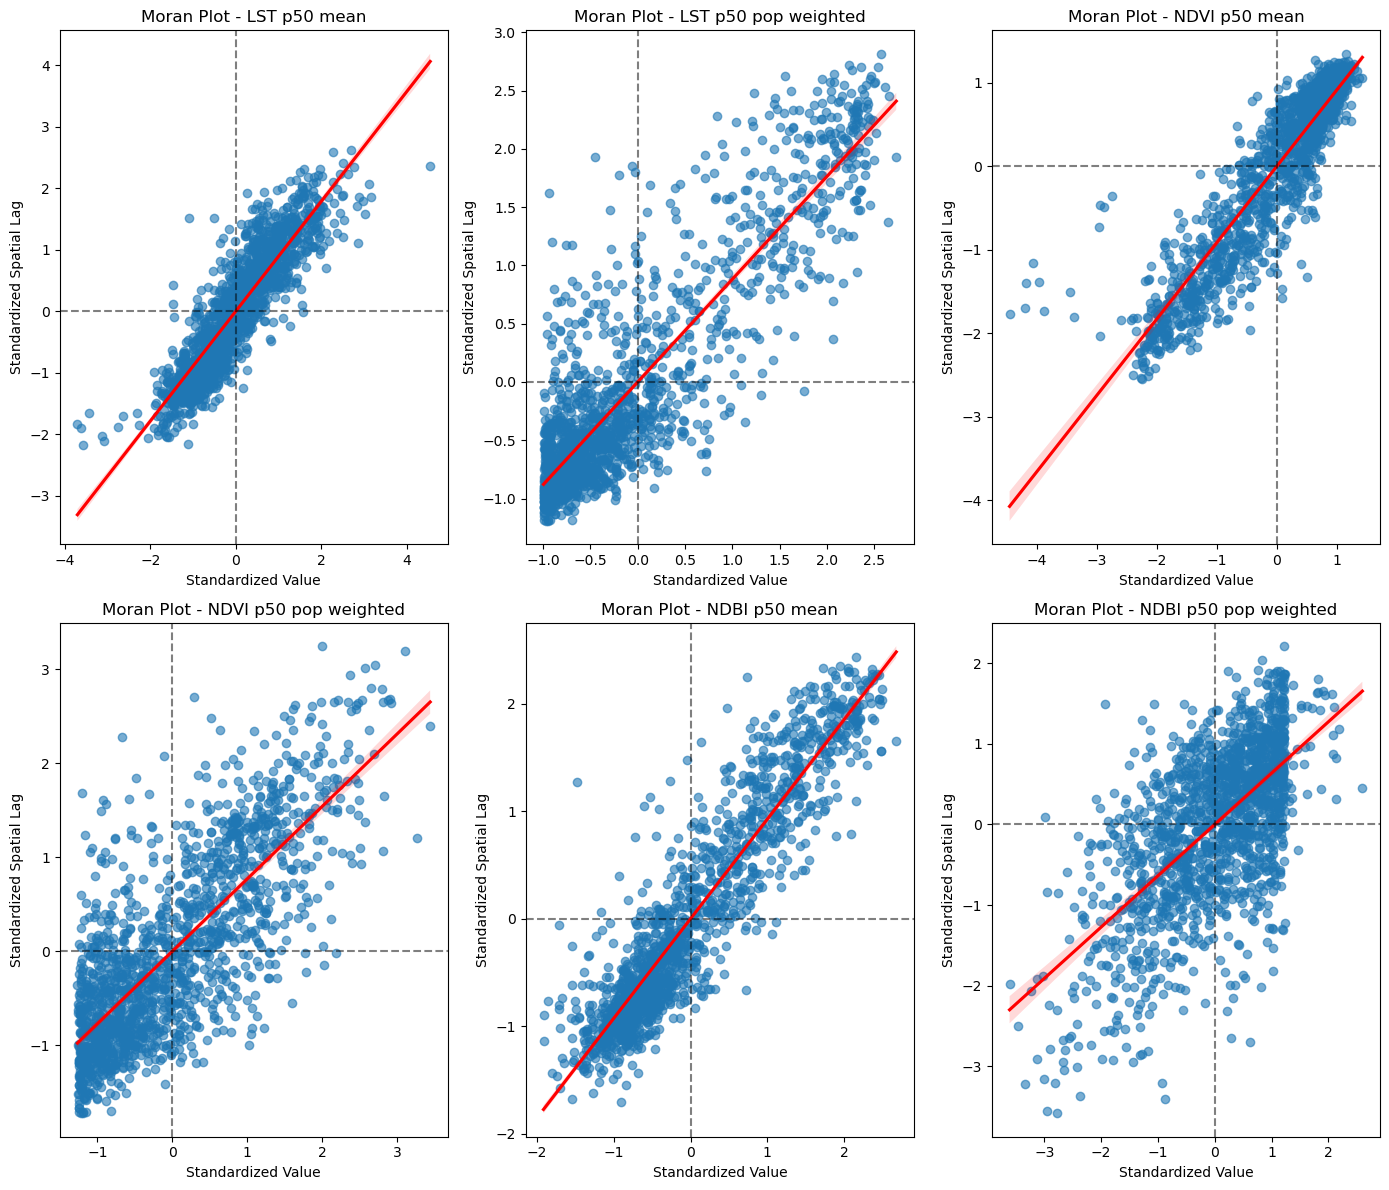

In [15]:
# MORAN SCATTER PLOTS 
# These plots visually confirm spatial autocorrelation for each variable.
# Each point represents a grid cell:
# - X-axis: standardized value at the cell
# - Y-axis: standardized average of neighboring cells (spatial lag)
#
# Interpretation:
# → Positive slope = clustering (similar values near similar values)
# → Flat slope = spatial randomness
# → Negative slope = spatial dispersion (rare in urban data)

print("\nGenerating Moran Plots...")

fig, axes = plt.subplots(2, 3, figsize=(14, 12))

vars_to_plot = variables
for i, var in enumerate(vars_to_plot):
    ax = axes.flatten()[i]
    
    # Standardized variable and its spatial lag
    y = gdf[var]
    # Compute spatial lag (average value of neighboring cells)
    # This captures local neighborhood influence
    y_lag = lps.weights.lag_spatial(w, y)

     # Standardize both original values and spatial lag
    # Standardization ensures comparability across variables with different scales
    y_std = (y - y.mean()) / y.std()
    y_lag_std = (y_lag - y_lag.mean()) / y_lag.std()
    
    # Scatter plot of value vs neighborhood influence
    # Regression line visually represents Moran's I relationship
    # Reference axes to interpret quadrants:
    # Top-right: high values surrounded by high values (hotspots)
    # Bottom-left: low values surrounded by low values (cold spots)
    sns.regplot(x=y_std, y=y_lag_std, ax=ax, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f"Moran Plot - {var.replace('_', ' ')}")
    ax.set_xlabel("Standardized Value")
    ax.set_ylabel("Standardized Spatial Lag")

plt.tight_layout()
plt.savefig("outputs/Moran_Plots.png", dpi=300, bbox_inches='tight')
plt.show()



# Local Moran's I

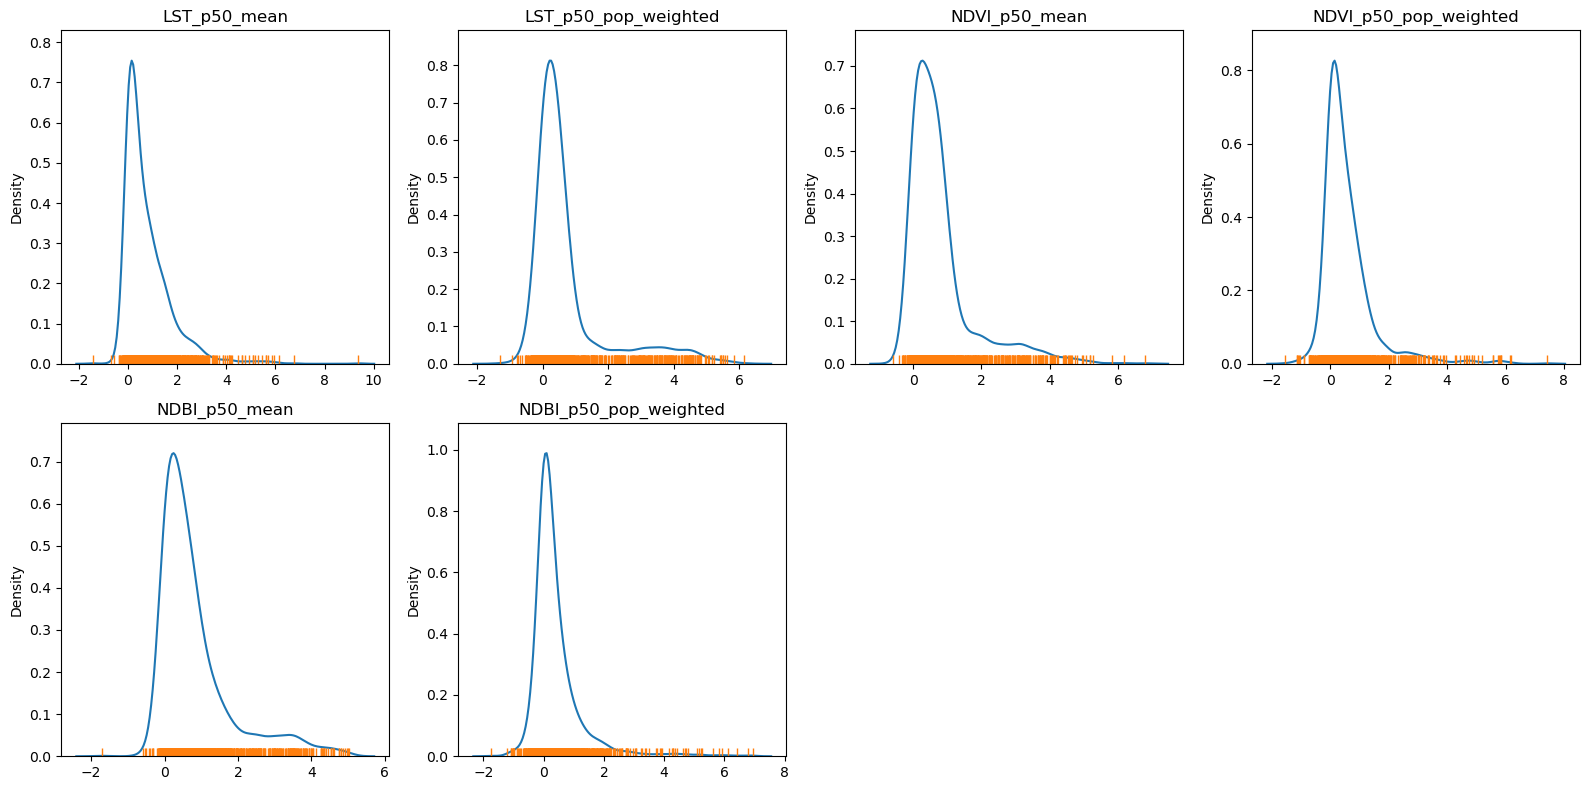

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# LOCAL SPATIAL AUTOCORRELATION (LISA) DISTRIBUTION PLOTS

# This section computes Local Moran's I for each variable and visualizes
# the distribution of local clustering strengths across all grid cells.
#
# Unlike Global Moran's I (single summary value),
# Local Moran reveals:
# → where clustering is strong or weak
# → whether spatial structure is uniform or heterogeneous

# Decide grid size automatically
n_vars = len(variables)
ncols = 4
nrows = math.ceil(n_vars / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4*ncols, 4*nrows)
)

# Flatten axes array so indexing is easier
axes = axes.flatten()

for i, var in enumerate(variables):

    # LOCAL MORAN'S I COMPUTATION
    # Computes a Local Moran statistic (Is) for each spatial unit
    # Each value represents how strongly a cell participates in clustering
    lisa = esda.moran.Moran_Local(gdf[var], w)
    
    # DISTRIBUTION VISUALIZATION
    # We plot the distribution of Local Moran values (Is)
    # to understand overall heterogeneity of spatial clustering
    sns.kdeplot(lisa.Is, ax=axes[i])

    # Rug plot shows individual observations (helps reveal skew/outliers)
    sns.rugplot(lisa.Is, ax=axes[i])

    axes[i].set_title(var)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Computing Local Indicators of Spatial Association (LISA) for LST_p50_mean


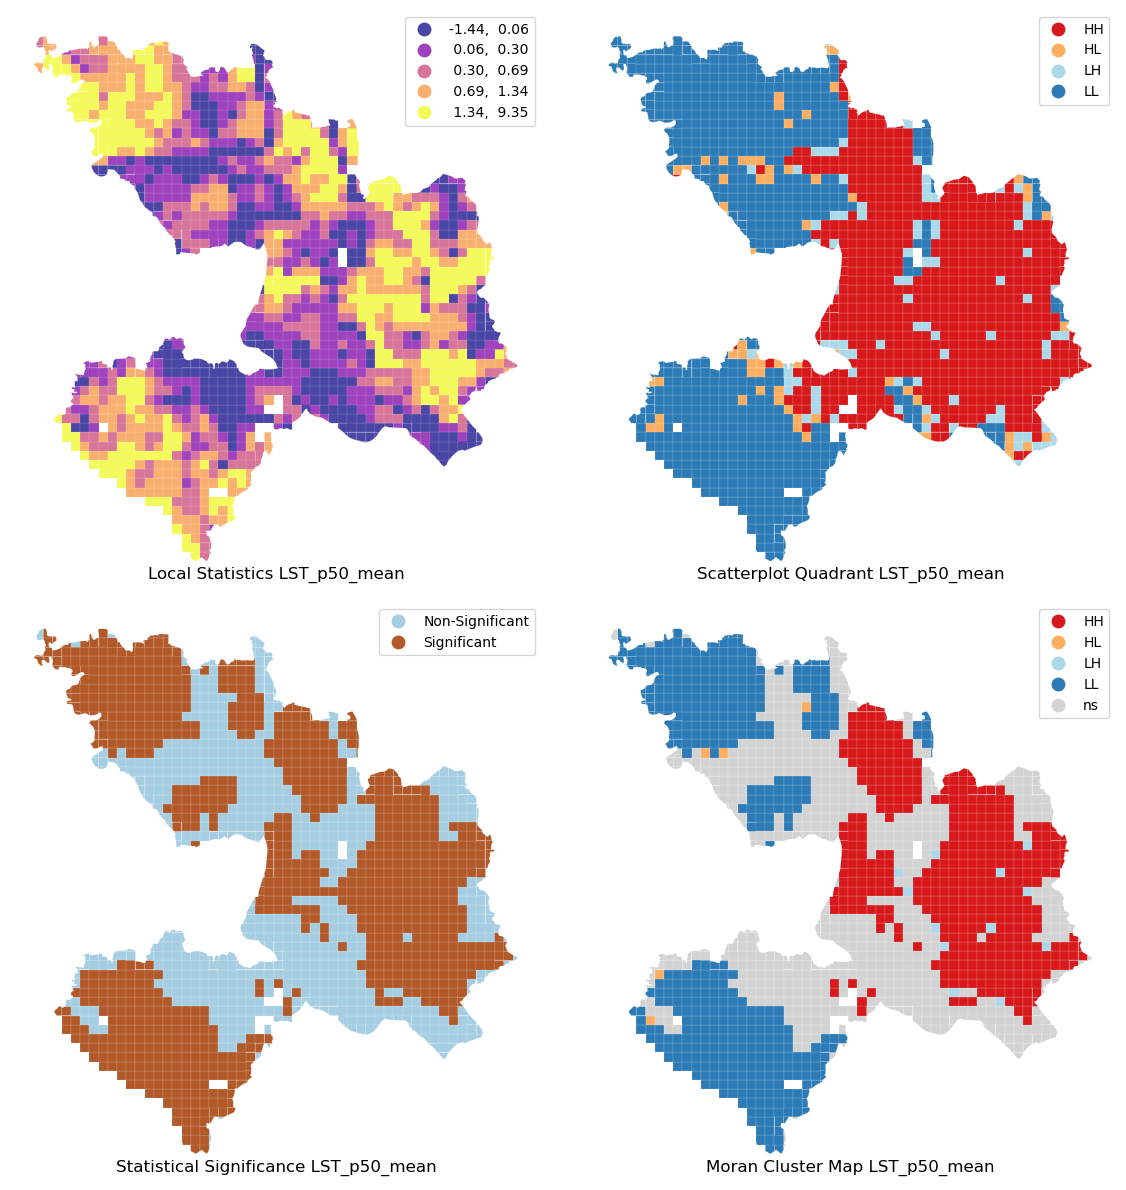


Computing Local Indicators of Spatial Association (LISA) for LST_p50_pop_weighted


<Figure size 640x480 with 0 Axes>

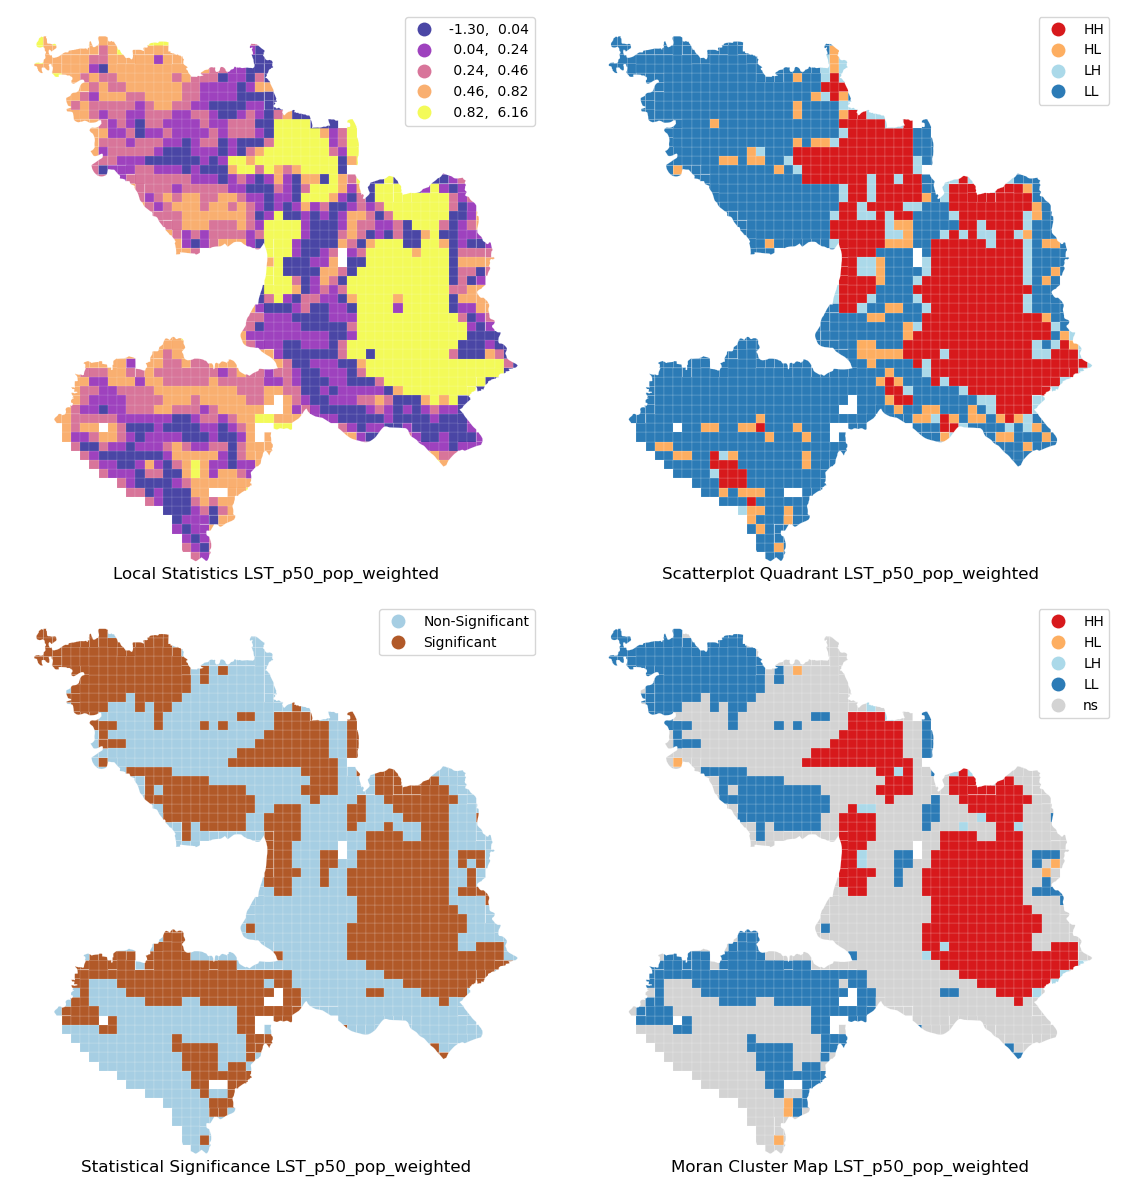


Computing Local Indicators of Spatial Association (LISA) for NDVI_p50_mean


<Figure size 640x480 with 0 Axes>

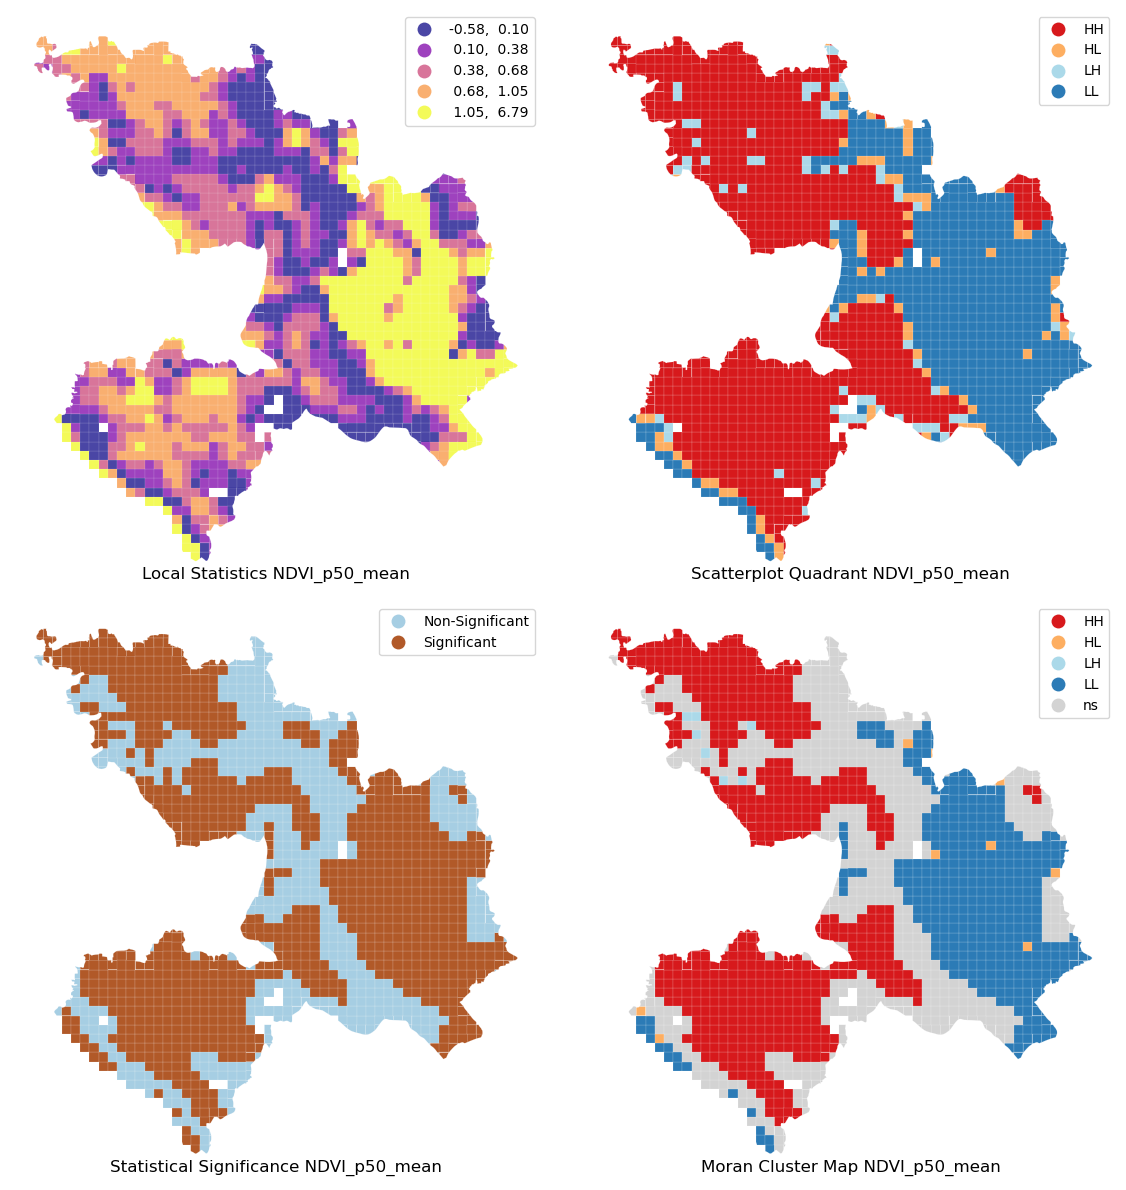


Computing Local Indicators of Spatial Association (LISA) for NDVI_p50_pop_weighted


<Figure size 640x480 with 0 Axes>

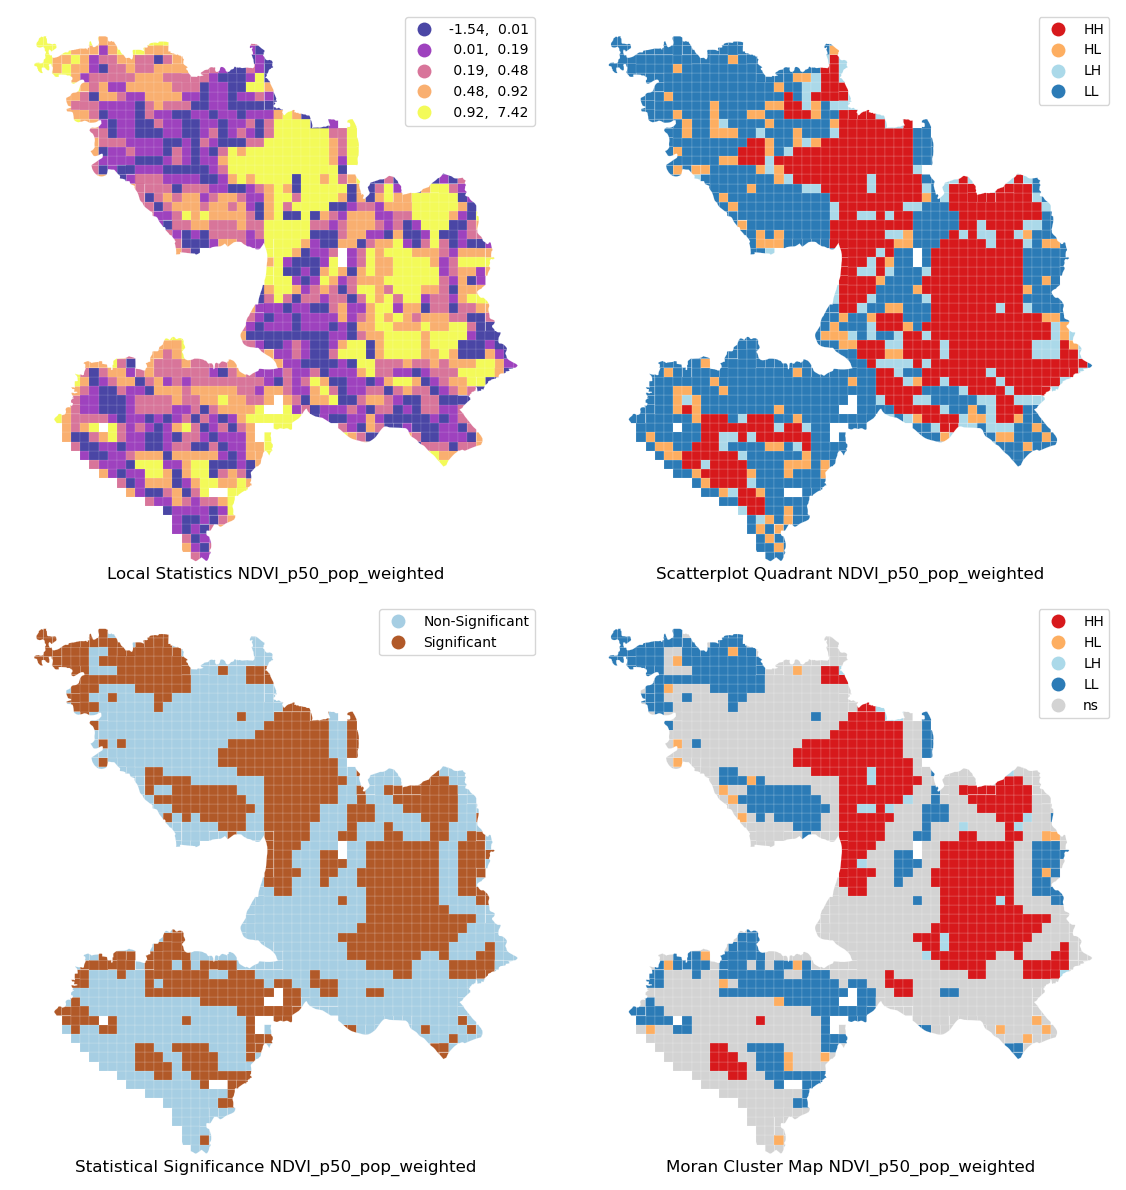


Computing Local Indicators of Spatial Association (LISA) for NDBI_p50_mean


<Figure size 640x480 with 0 Axes>

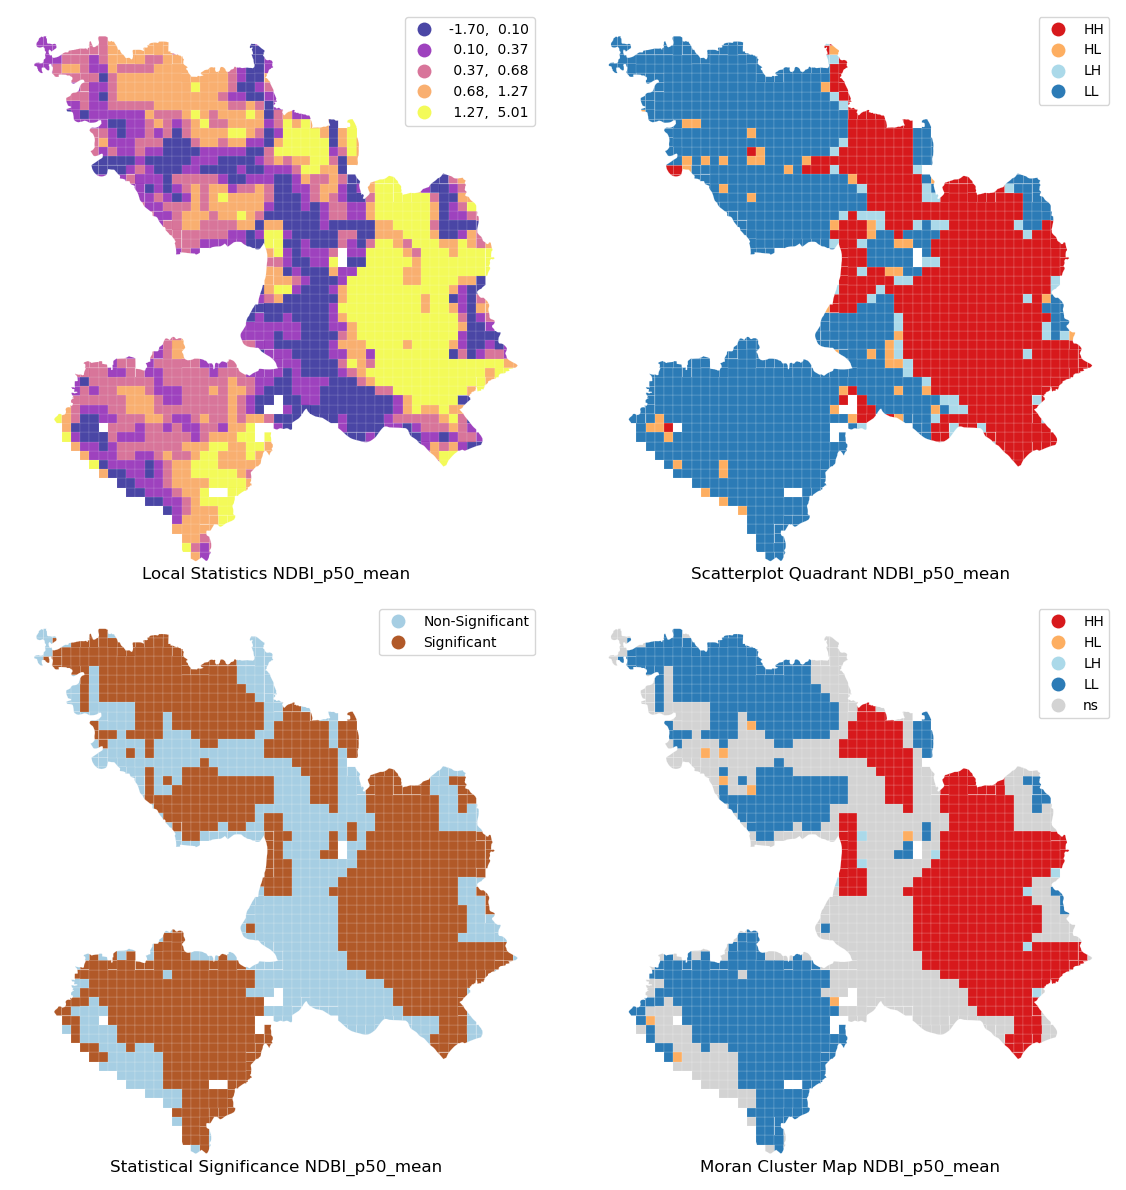


Computing Local Indicators of Spatial Association (LISA) for NDBI_p50_pop_weighted


<Figure size 640x480 with 0 Axes>

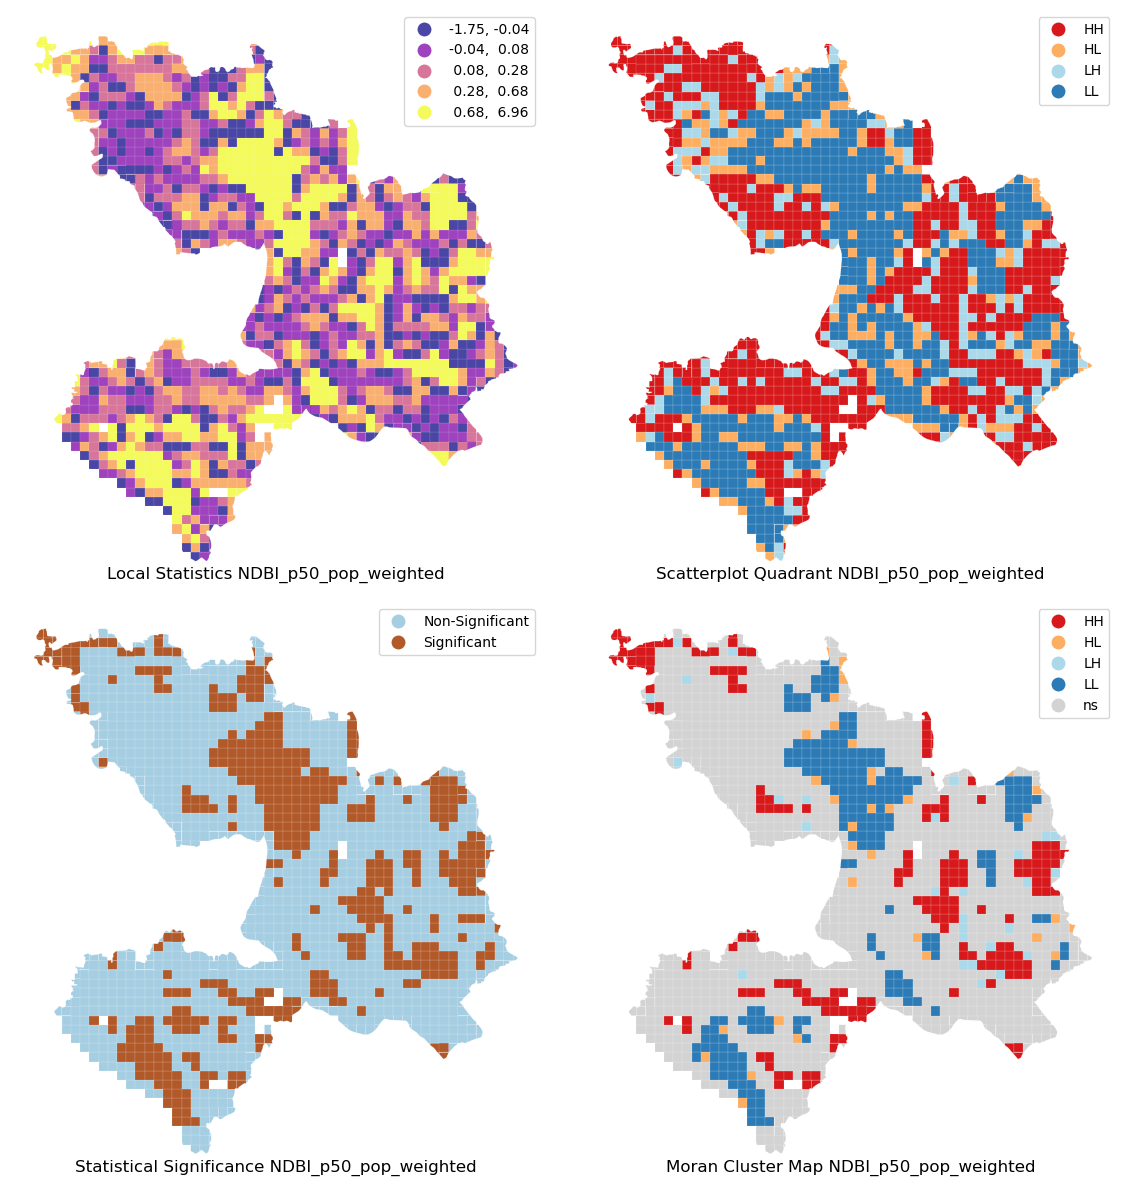

<Figure size 640x480 with 0 Axes>

In [17]:
# ========================= LISA (Local Moran's I) =========================
rows=[]
for var in variables:
    print(f"\nComputing Local Indicators of Spatial Association (LISA) for {var}")

    # Compute Local Moran's I for each spatial unit
    # This tells us whether each cell is:
    # - part of a cluster (high-high / low-low)
    # - an outlier (high-low / low-high)
    lisa = esda.Moran_Local(gdf[var], w, transformation='r')

    # Add results to GeoDataFrame

     # Store outputs back into GeoDataFrame for later mapping and export
    # q → quadrant classification (1–4: HH, LL, LH, HL)
    gdf[f'LISA_cluster_{var}'] = lisa.q

    # p-values tell us whether local clustering is statistically meaningful
    gdf[f'LISA_pvalue_{var}'] = lisa.p_sim

    # p-values tell us whether local clustering is statistically meaningful
    gdf[f'LISA_sig_{var}'] = gdf[f'LISA_pvalue_{var}'] < 0.05

    from splot import esda as esdaplot
    db=gdf
    # Set up figure and axes
    f, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
    # Make the axes accessible with single indexing
    axs = axs.flatten()

    # -------------------------------------------------
    # (1) Local Moran statistic intensity map (Is)
    # -------------------------------------------------
    # Shows where clustering strength is high or low (regardless of type)

    # Subplot 1 #
    # Choropleth of local statistics
    # Grab first axis in the figure
    ax = axs[0]
    # Assign new column with local statistics on-the-fly
    db.assign(
        Is=lisa.Is
        # Plot choropleth of local statistics
    ).plot(
        column="Is",
        cmap="plasma",
        scheme="quantiles",
        k=5,
        edgecolor="white",
        linewidth=0.1,
        alpha=0.75,
        legend=True,
        ax=ax,
    )
    # -------------------------------------------------
    # (2) Cluster type map (quadrants)
    # -------------------------------------------------
    # Shows *what type* of spatial relationship each cell belongs to:
    # HH = high surrounded by high (hotspot)
    # LL = low surrounded by low (coldspot)
    # HL/LH = spatial outliers

    # Subplot 2 #
    # Quadrant categories
    # Grab second axis of local statistics
    ax = axs[1]
    # Plot Quadrant colors (note to ensure all polygons are assigned a
    # quadrant, we "trick" the function by setting significance level to
    # 1 so all observations are treated as "significant" and thus assigned
    # a quadrant color
    esdaplot.lisa_cluster(lisa, db, p=1, ax=ax)

    # -------------------------------------------------
    # (3) Statistical significance map
    # -------------------------------------------------
    # Separates meaningful clustering from random spatial noise

    # Subplot 3 #
    # Significance map
    # Grab third axis of local statistics
    ax = axs[2]
    #
    # Find out significant observations
    labels = pd.Series(
        1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
        index=db.index  # Use the index in the original data
        # Recode 1 to "Significant and 0 to "Non-significant"
    ).map({1: "Significant", 0: "Non-Significant"})
    # Assign labels to `db` on the fly
    db.assign(
        cl=labels
        # Plot choropleth of (non-)significant areas
    ).plot(
        column="cl",
        categorical=True,
        k=2,
        cmap="Paired",
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        ax=ax,
    )

    # -------------------------------------------------
    # (4) Final cluster map (filtered by significance)
    # -------------------------------------------------
    # This is the most interpretable output:
    # only statistically meaningful clusters are emphasized
    
    # Subplot 4 #
    # Cluster map
    # Grab second axis of local statistics
    ax = axs[3]
    # Plot Quadrant colors In this case, we use a 5% significance
    # level to select polygons as part of statistically significant
    # clusters
    esdaplot.lisa_cluster(lisa, db, p=0.05, ax=ax)

    # Figure styling #
    # Set title to each subplot
    for i, ax in enumerate(axs.flatten()):
        ax.set_axis_off()
        ax.set_title(
            [
                f"Local Statistics {var}",
                f"Scatterplot Quadrant {var}",
                f"Statistical Significance {var}",
                f"Moran Cluster Map {var}",
            ][i],
            y=0,
        )
    # Tight layout to minimize in-between white space
    f.tight_layout()

    # Display the figure
    plt.show()
    plt.savefig(f"outputs/local_moran_{var}.png", dpi=300, bbox_inches='tight')
    plt.close(f)
   



# Getis and Ord's local statistics

Getis–Ord local statistics are a way to detect local clustering of high or low values in spatial data. Unlike Moran’s I (which is about correlation), Getis–Ord G
i and Gi\* directly measure “is this location surrounded by unusually high (or low) values?"

For each location i:

Are high values clustering around it? → hotspot
Are low values clustering around it? → coldspot
Or is it just random?

So instead of correlation, it measures local intensity of values in the neighborhood.

Output types:
- Z>+1.96 → statistically significant hotspot
- Z<−1.96 → statistically significant coldspot
- between → not significant clustering

In [18]:
def g_map(g, db, ax,var=""):
    """
    Create a cluster map
    ...

    Arguments
    ---------
    g      : G_Local
             Object from the computation of the G statistic
    db     : GeoDataFrame
             Table aligned with values in `g` and containing
             the geometries to plot
    ax     : AxesSubplot
             `matplotlib` axis to draw the map on

    Returns
    -------
    ax     : AxesSubplot
             Axis with the map drawn
    """
    ec = "0.8"

    # Break observations into significant or not
    sig = g.p_sim < 0.05

    # Plot non-significant clusters
    ns = db.loc[sig == False, "geometry"]
    ns.plot(ax=ax, color="lightgrey", edgecolor=ec, linewidth=0.1)
    # Plot HH clusters
    hh = db.loc[(g.Zs > 0) & (sig == True), "geometry"]
    hh.plot(ax=ax, color="red", edgecolor=ec, linewidth=0.1)
    # Plot LL clusters
    ll = db.loc[(g.Zs < 0) & (sig == True), "geometry"]
    ll.plot(ax=ax, color="blue", edgecolor=ec, linewidth=0.1)
    # Style and draw
    contextily.add_basemap(
    ax,
    source=contextily.providers.OpenStreetMap.Mapnik
    )
    # Flag to add a star to the title if it's G_i*
    st = ""
    if g.star:
        st = "*"
    # Add title
    ax.set_title(f"G{st} statistic for {var}", size=15)
    # Remove axis for aesthetics
    ax.set_axis_off()
    return ax

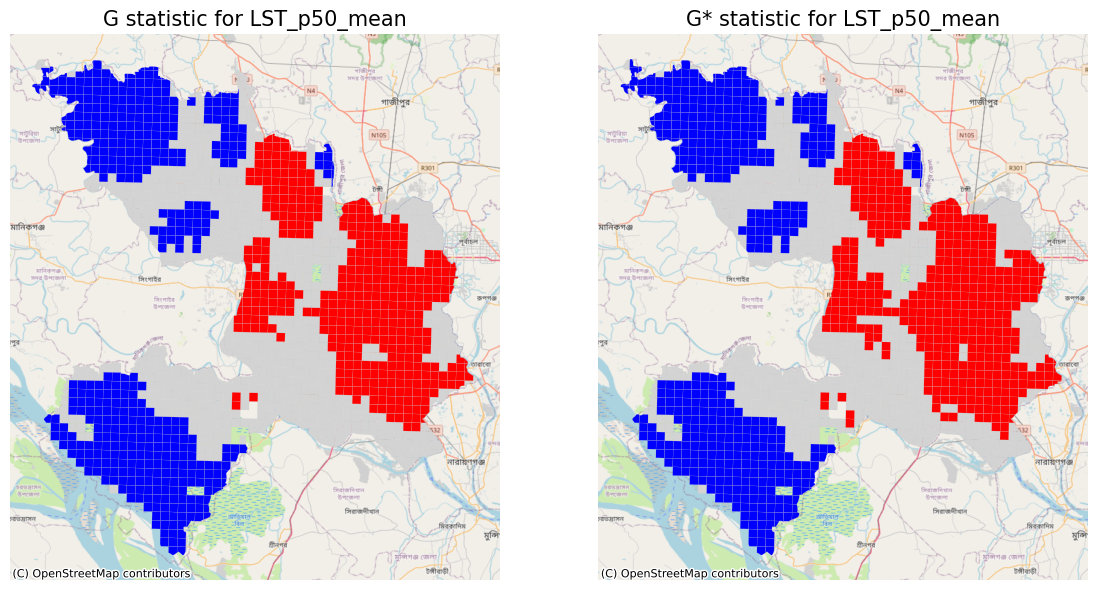

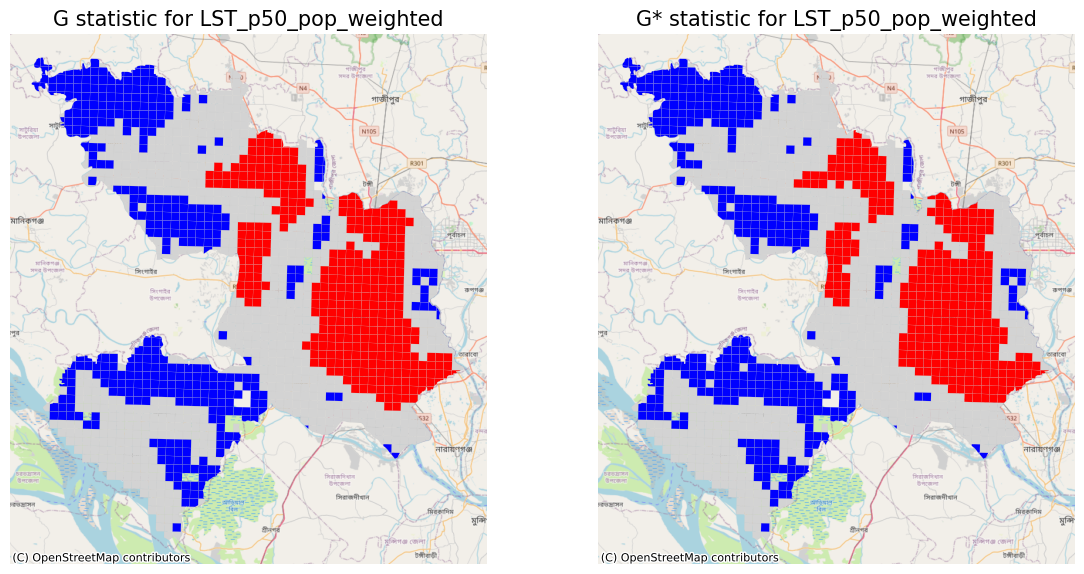

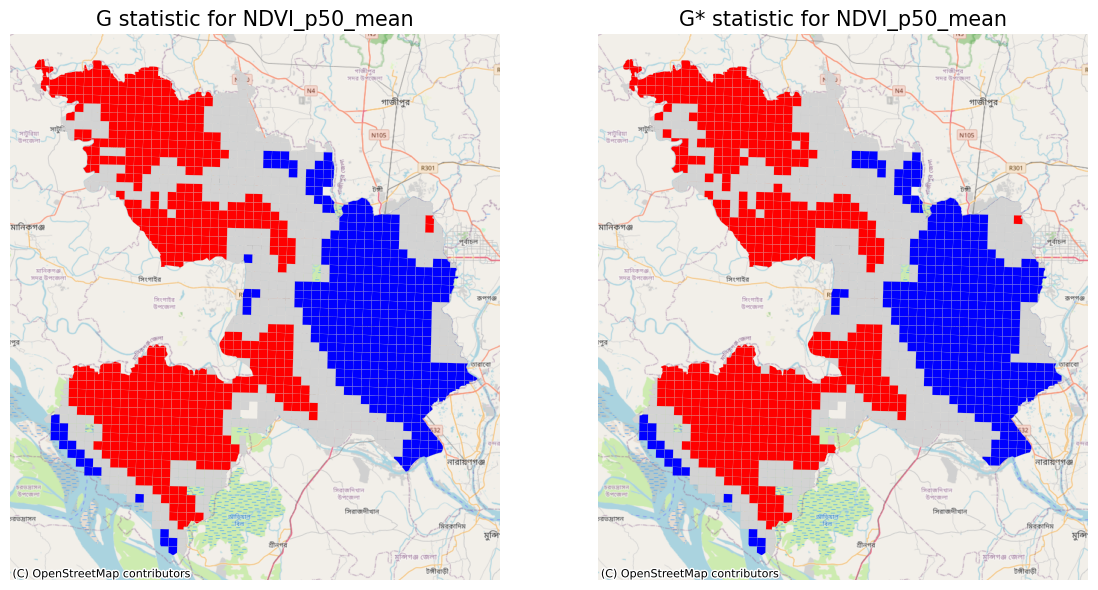

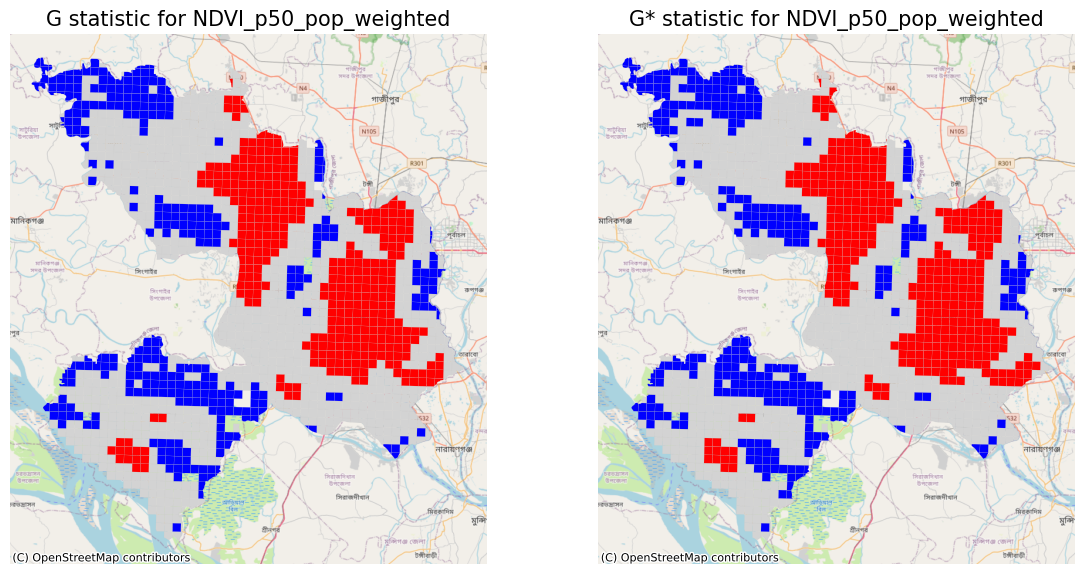

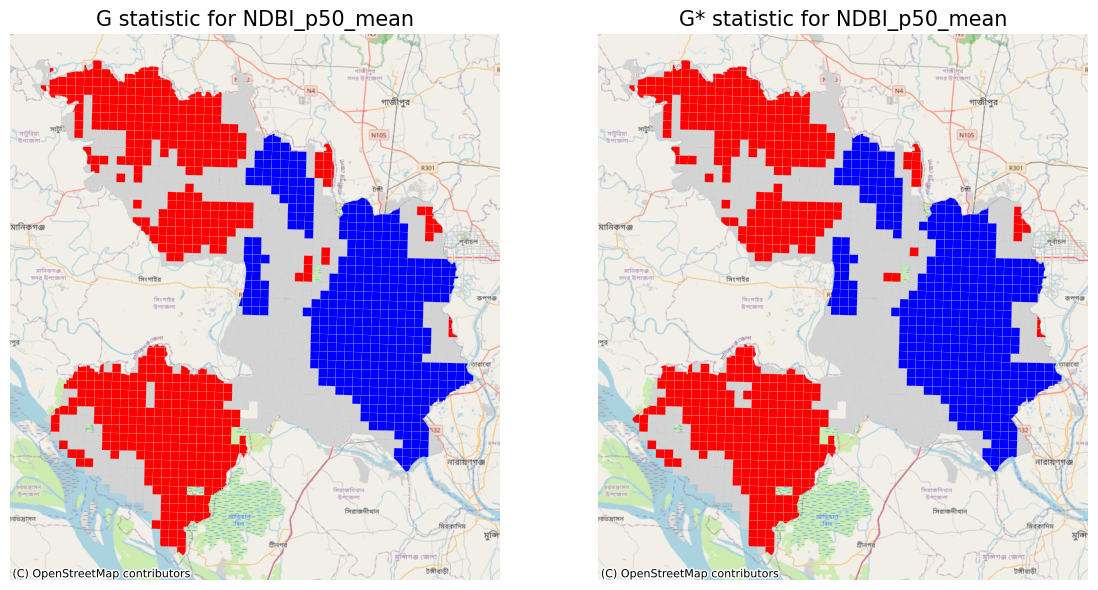

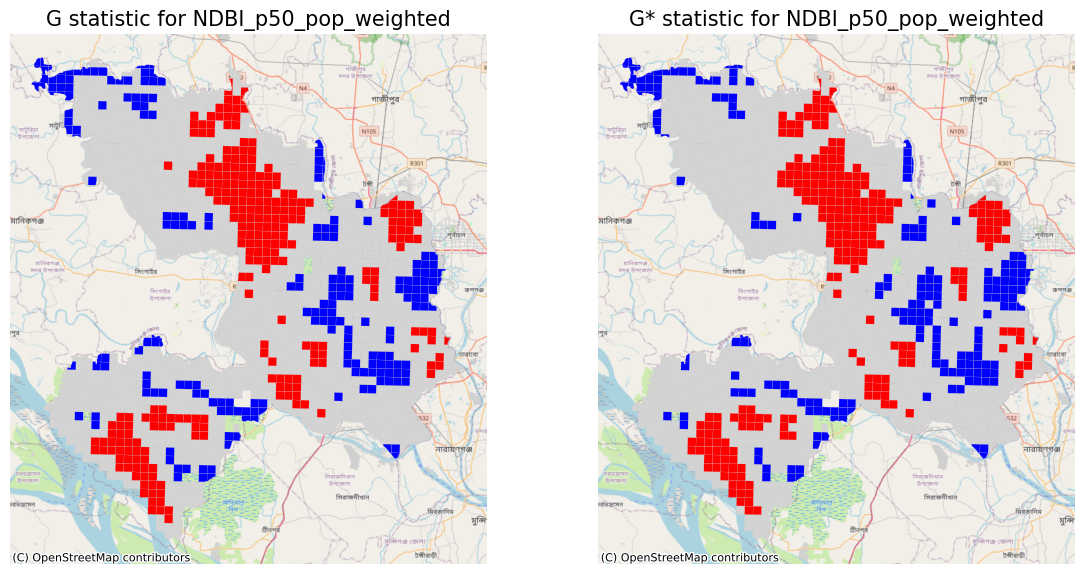

In [28]:
import contextily
db = db.to_crs(epsg=3857)
for var in variables:
    # Gi
    go_i = esda.getisord.G_Local(db[var], w)
    # Gi*
    go_i_star = esda.getisord.G_Local(db[var], w, star=True)
    # Set up figure and axes
    f, axs = plt.subplots(1, 2, figsize=(12, 6))
    # Loop over the two statistics
    for g, ax in zip([go_i, go_i_star], axs.flatten()):
        # Generate the statistic's map
        ax = g_map(g, db, ax,var)
    # Tight layout to minimise blank spaces
    f.tight_layout()
    # Render
    plt.savefig(f"outputs/getisord_{var}.png", dpi=300, bbox_inches='tight')
    plt.show()


In [20]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [21]:
def summarize(results):
    coef_table = pd.DataFrame({
        "coef": results.params,
        "std err": results.bse,
        "t": results.tvalues,
        "P>|t|": results.pvalues.round(4),
    })
    print("\n" + "=" * 80)
    print("OLS REGRESSION RESULTS")
    print("=" * 80)
    print(coef_table)
    print(f"\nR-squared: {results.rsquared:.4f} | Adj. R-squared: {results.rsquared_adj:.4f}")
    print(f"F-statistic: {results.fvalue:.2f} (p = {results.f_pvalue:.2e})")

In [22]:
print("Loading cleaned grid...")
gdf = gpd.read_file("outputs/grid/dhaka_grid_stats_clean.gpkg")

df = pd.DataFrame(gdf.drop(columns=["geometry"]))

print(f"Observations: {len(df)}")
print(f"Total Population: {df['pop_sum'].sum():,.0f}")

Loading cleaned grid...
Observations: 1551
Total Population: 12,223,478



1. Simple Linear Regression: LST ~ NDVI

OLS REGRESSION RESULTS
                    coef   std err           t  P>|t|
const          31.950831  0.121147  263.736934    0.0
NDVI_p50_mean  -5.685221  0.251887  -22.570505    0.0

R-squared: 0.2475 | Adj. R-squared: 0.2470
F-statistic: 509.43 (p = 9.35e-98)


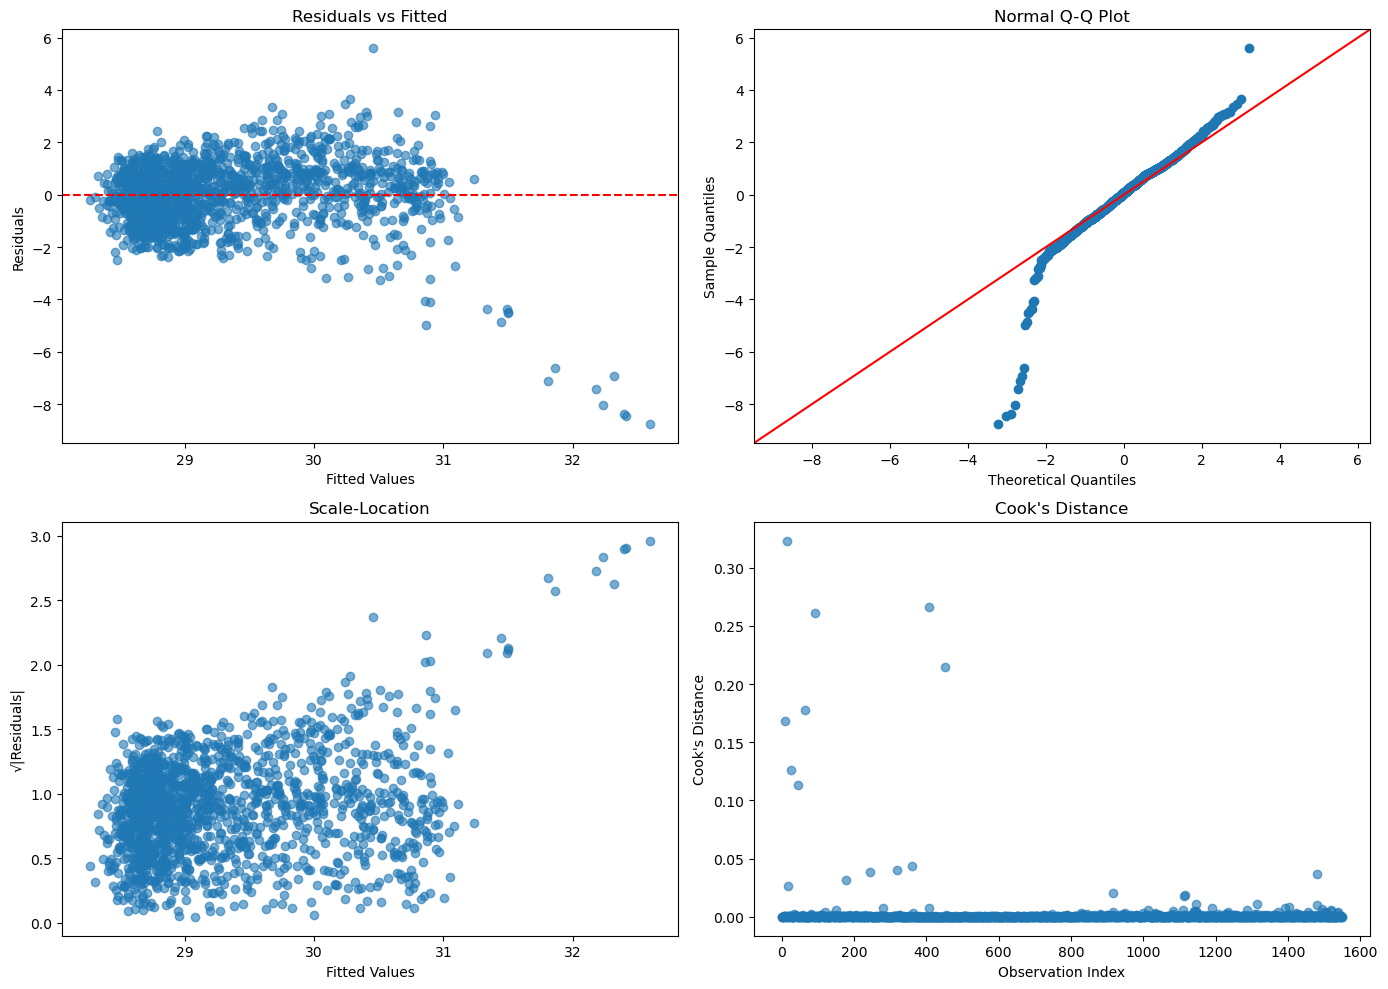

In [23]:
y = df["LST_p50_mean"]

# 1. Simple Regression: LST ~ NDVI
print("\n1. Simple Linear Regression: LST ~ NDVI")
X1 = sm.add_constant(df[["NDVI_p50_mean"]])
model1 = sm.OLS(y, X1).fit()
summarize(model1)


# ========================= DIAGNOSTICS =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(model1.fittedvalues, model1.resid, alpha=0.6)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

sm.qqplot(model1.resid, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot")

axes[1, 0].scatter(model1.fittedvalues, np.sqrt(np.abs(model1.resid)), alpha=0.6)
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("√|Residuals|")
axes[1, 0].set_title("Scale-Location")

influence = model1.get_influence()
axes[1, 1].scatter(range(len(influence.cooks_distance[0])), influence.cooks_distance[0], alpha=0.6)
axes[1, 1].set_xlabel("Observation Index")
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].set_title("Cook's Distance")

plt.tight_layout()
plt.savefig("outputs/model1_OLS_Diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


2. Multiple Linear Regression (with Population)

OLS REGRESSION RESULTS
                    coef   std err           t   P>|t|
const          31.488087  0.115295  273.109108  0.0000
NDVI_p50_mean   2.637931  0.239831   10.999105  0.0000
NDBI_p50_mean  18.417886  0.483844   38.065746  0.0000
pop_sum        -0.000012  0.000004   -2.823844  0.0048

R-squared: 0.6901 | Adj. R-squared: 0.6895
F-statistic: 1148.25 (p = 0.00e+00)

5. Variance Inflation Factors (Multicollinearity Check)
         Feature    VIF
0          const  30.33
1  NDVI_p50_mean   2.20
2  NDBI_p50_mean   3.67
3        pop_sum   2.37


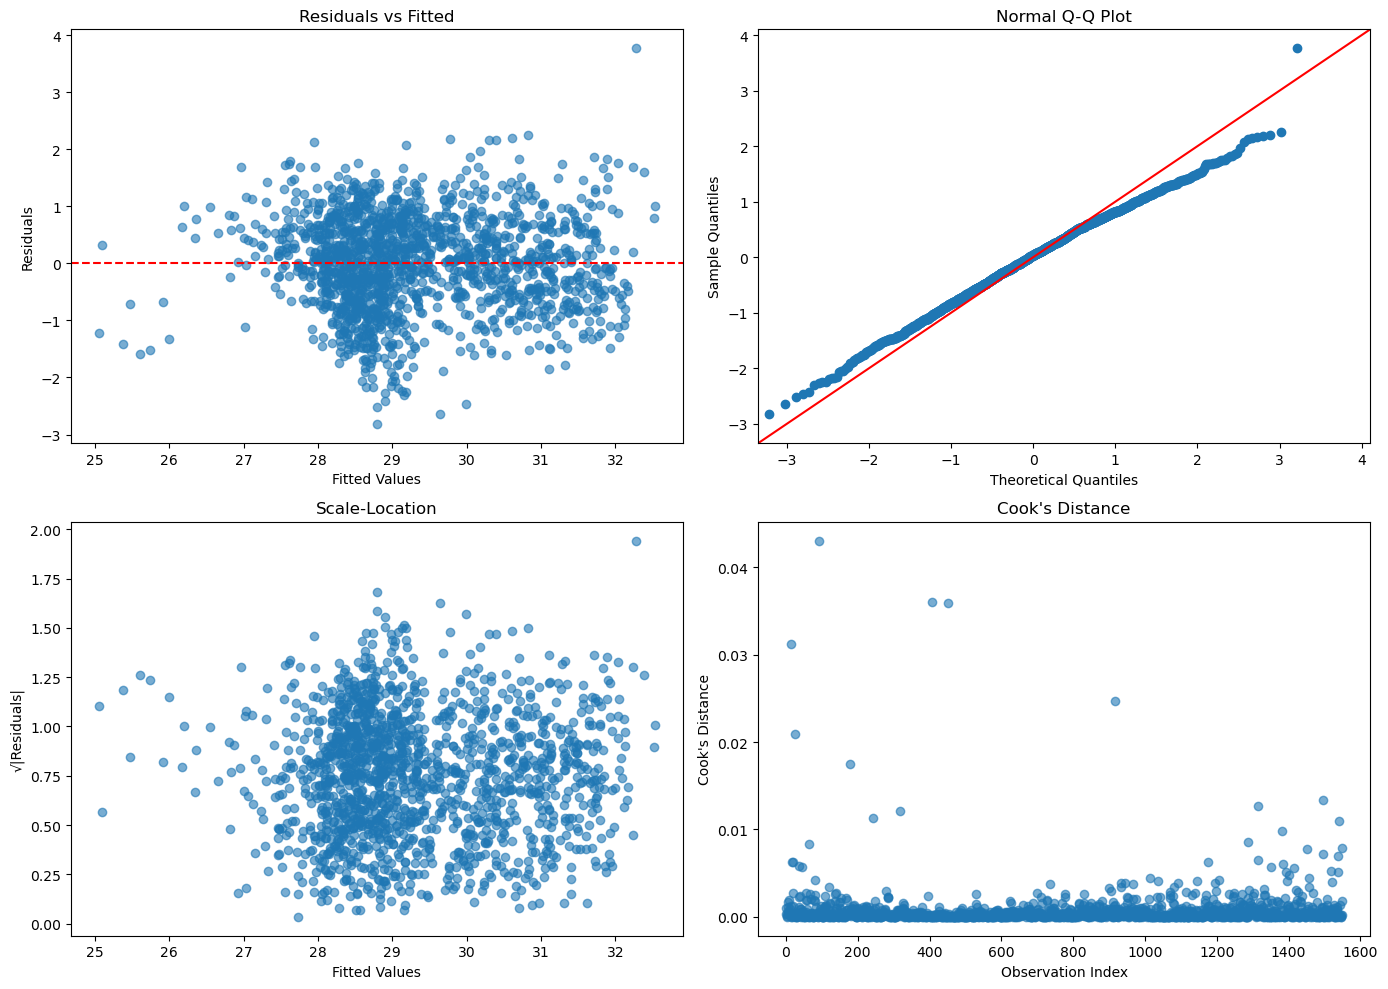

In [24]:
# 2. Main Multiple Regression (Using pop_sum)
print("\n2. Multiple Linear Regression (with Population)")
X2 = df[["NDVI_p50_mean", "NDBI_p50_mean", "pop_sum"]].copy()
X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()
summarize(model2)

# ========================= VIF =========================
print("\n5. Variance Inflation Factors (Multicollinearity Check)")
vif_data = pd.DataFrame()
vif_data["Feature"] = X2.columns
vif_data["VIF"] = [VIF(X2.values, i) for i in range(X2.shape[1])]
print(vif_data.round(2))

# ========================= DIAGNOSTICS =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(model2.fittedvalues, model2.resid, alpha=0.6)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

sm.qqplot(model2.resid, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot")

axes[1, 0].scatter(model2.fittedvalues, np.sqrt(np.abs(model2.resid)), alpha=0.6)
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("√|Residuals|")
axes[1, 0].set_title("Scale-Location")

influence = model2.get_influence()
axes[1, 1].scatter(range(len(influence.cooks_distance[0])), influence.cooks_distance[0], alpha=0.6)
axes[1, 1].set_xlabel("Observation Index")
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].set_title("Cook's Distance")

plt.tight_layout()
plt.savefig("outputs/model2_OLS_Diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()


3. Model with Interaction (NDVI × NDBI)

OLS REGRESSION RESULTS
                    coef   std err           t   P>|t|
const          31.226942  0.188416  165.733875  0.0000
NDVI_p50_mean   3.402333  0.497866    6.833839  0.0000
NDBI_p50_mean  17.097665  0.895452   19.093900  0.0000
pop_sum        -0.000011  0.000004   -2.533375  0.0114
NDVI_NDBI_int   3.721106  2.124298    1.751687  0.0800

R-squared: 0.6907 | Adj. R-squared: 0.6899
F-statistic: 863.11 (p = 0.00e+00)

5. Variance Inflation Factors (Multicollinearity Check)
         Feature    VIF
0          const  81.11
1  NDVI_p50_mean   9.49
2  NDBI_p50_mean  12.59
3        pop_sum   2.43
4  NDVI_NDBI_int  27.43


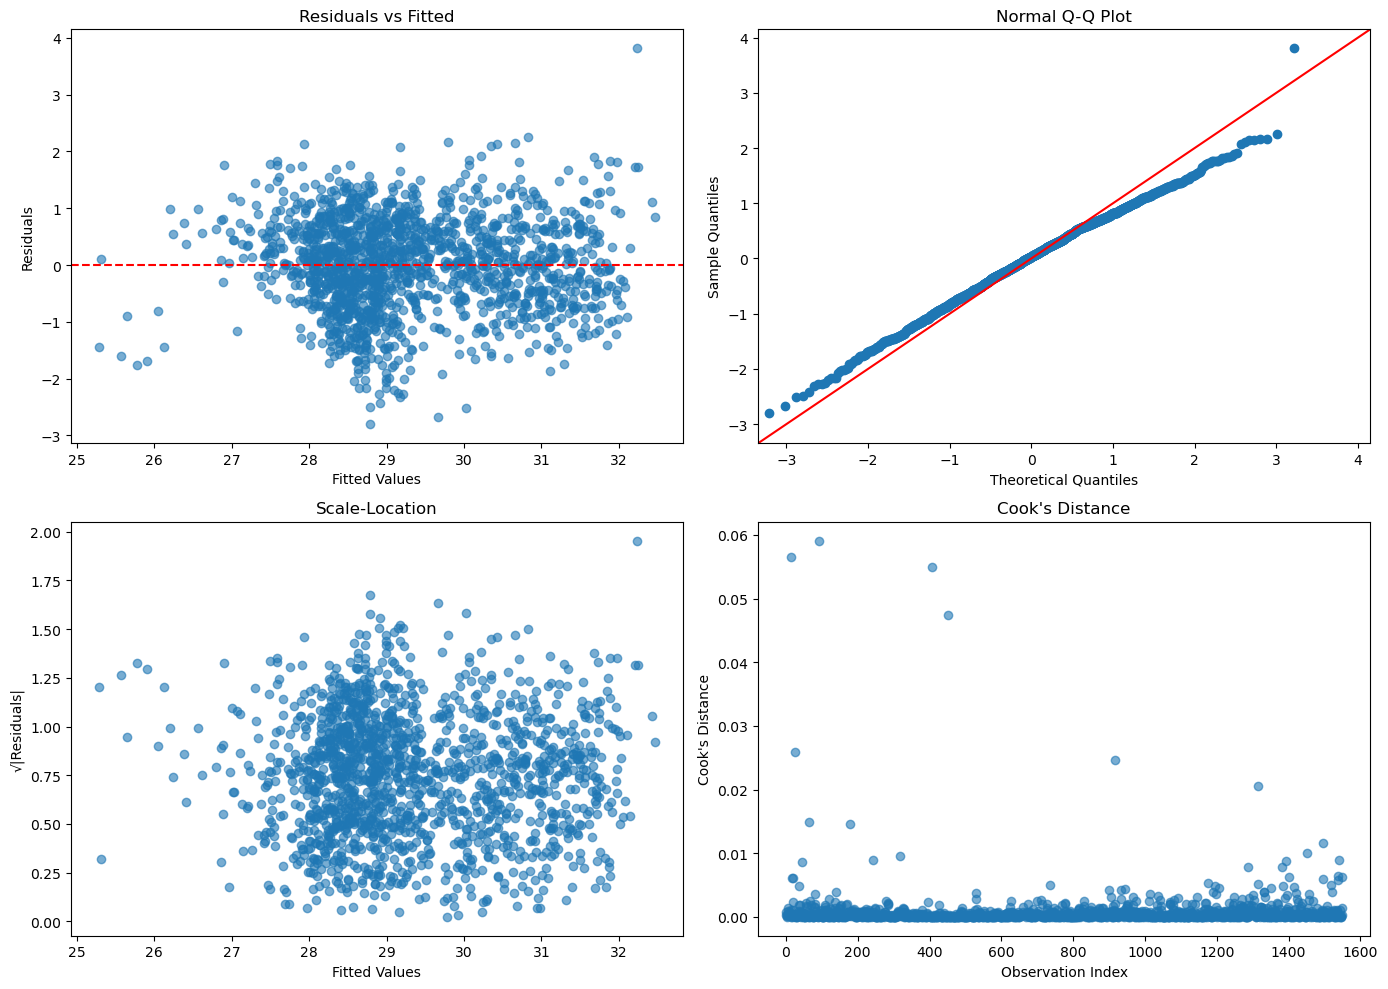

In [25]:
# 3. Model with Interaction
print("\n3. Model with Interaction (NDVI × NDBI)")
X3 = df[["NDVI_p50_mean", "NDBI_p50_mean", "pop_sum"]].copy()
X3["NDVI_NDBI_int"] = X3["NDVI_p50_mean"] * X3["NDBI_p50_mean"]
X3 = sm.add_constant(X3)

model3 = sm.OLS(y, X3).fit()
summarize(model3)

# ========================= VIF =========================
print("\n5. Variance Inflation Factors (Multicollinearity Check)")
vif_data = pd.DataFrame()
vif_data["Feature"] = X3.columns
vif_data["VIF"] = [VIF(X3.values, i) for i in range(X3.shape[1])]
print(vif_data.round(2))

# ========================= DIAGNOSTICS =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(model3.fittedvalues, model3.resid, alpha=0.6)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

sm.qqplot(model3.resid, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot")

axes[1, 0].scatter(model3.fittedvalues, np.sqrt(np.abs(model3.resid)), alpha=0.6)
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("√|Residuals|")
axes[1, 0].set_title("Scale-Location")

influence = model3.get_influence()
axes[1, 1].scatter(range(len(influence.cooks_distance[0])), influence.cooks_distance[0], alpha=0.6)
axes[1, 1].set_xlabel("Observation Index")
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].set_title("Cook's Distance")

plt.tight_layout()
plt.savefig("outputs/model3_OLS_Diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()



4. Quadratic Model

OLS REGRESSION RESULTS
                    coef   std err           t  P>|t|
const          30.256465  0.196663  153.849678  0.000
NDVI_p50_mean   8.983488  0.861354   10.429491  0.000
NDBI_p50_mean  16.679860  0.526491   31.681186  0.000
pop_sum        -0.000007  0.000004   -1.769812  0.077
NDVI_sq        -8.882141  1.159742   -7.658718  0.000

R-squared: 0.7014 | Adj. R-squared: 0.7006
F-statistic: 907.95 (p = 0.00e+00)

5. Variance Inflation Factors (Multicollinearity Check)
         Feature    VIF
0          const  91.53
1  NDVI_p50_mean  29.41
2  NDBI_p50_mean   4.51
3        pop_sum   2.42
4        NDVI_sq  34.60


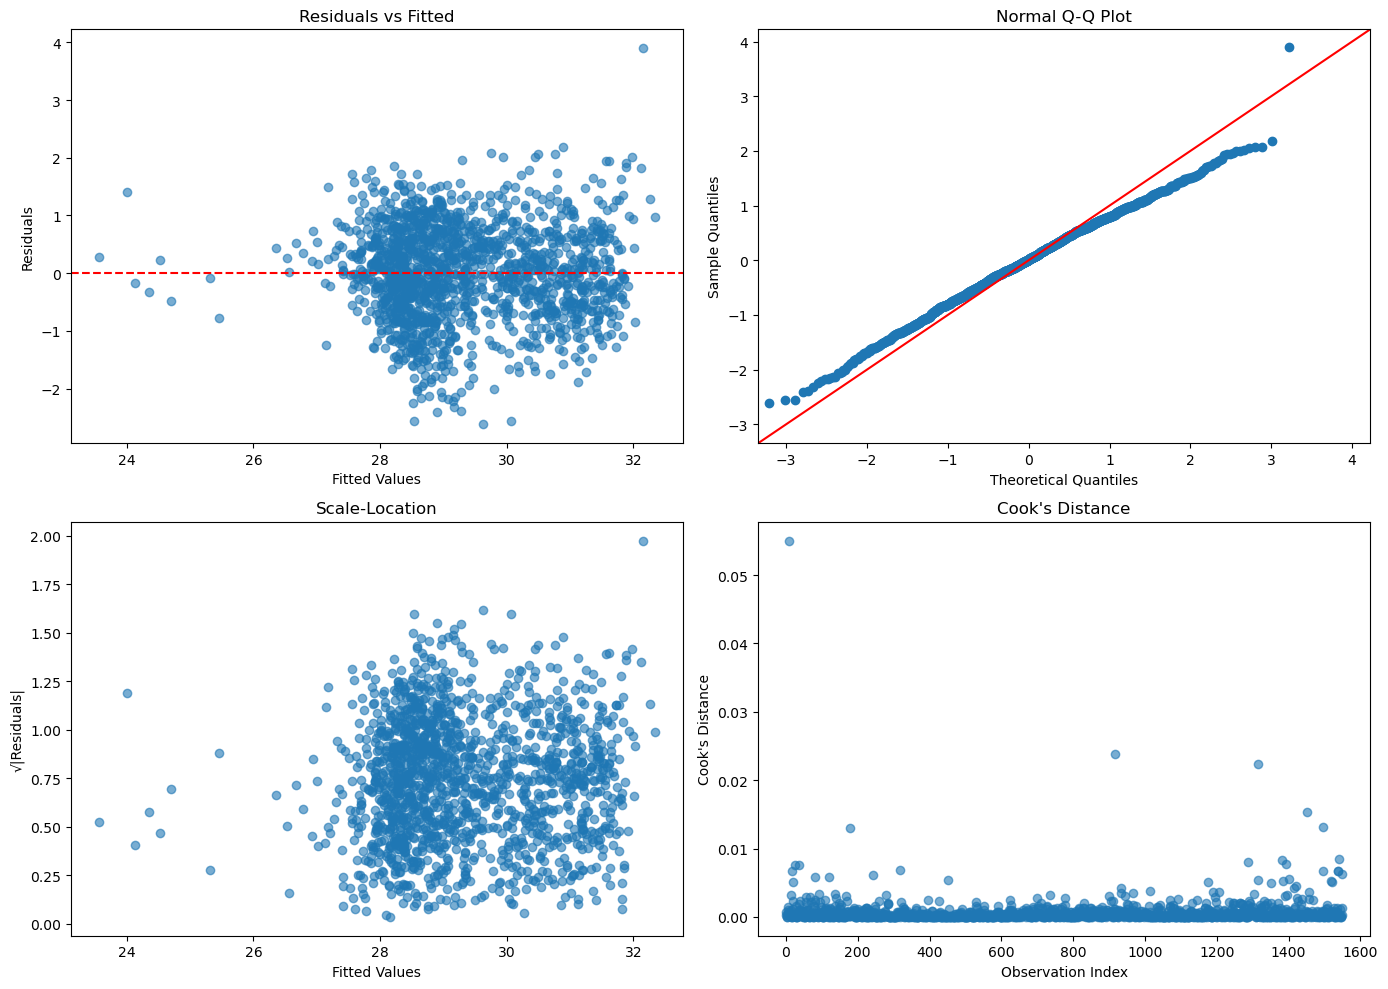

In [26]:
# 4. Quadratic NDVI
print("\n4. Quadratic Model")
X4 = df[["NDVI_p50_mean", "NDBI_p50_mean", "pop_sum"]].copy()
X4["NDVI_sq"] = X4["NDVI_p50_mean"] ** 2
X4 = sm.add_constant(X4)

model4 = sm.OLS(y, X4).fit()
summarize(model4)

# ========================= VIF =========================
print("\n5. Variance Inflation Factors (Multicollinearity Check)")
vif_data = pd.DataFrame()
vif_data["Feature"] = X4.columns
vif_data["VIF"] = [VIF(X4.values, i) for i in range(X4.shape[1])]
print(vif_data.round(2))

# ========================= DIAGNOSTICS =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(model4.fittedvalues, model4.resid, alpha=0.6)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

sm.qqplot(model4.resid, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot")

axes[1, 0].scatter(model4.fittedvalues, np.sqrt(np.abs(model4.resid)), alpha=0.6)
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("√|Residuals|")
axes[1, 0].set_title("Scale-Location")

influence = model4.get_influence()
axes[1, 1].scatter(range(len(influence.cooks_distance[0])), influence.cooks_distance[0], alpha=0.6)
axes[1, 1].set_xlabel("Observation Index")
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].set_title("Cook's Distance")

plt.tight_layout()
plt.savefig("outputs/model4_OLS_Diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()
